In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
from pathlib import Path

p = Path('data/processed/train_data.parquet')

if p.exists():
    df = pd.read_parquet(p)
else:
    alternatives = [
        Path('data/processed/train.parquet'),
        Path('data/train_data.parquet'),
        Path('../data/processed/train_data.parquet'),
    ]
    found = next((a for a in alternatives if a.exists()), None)
    if found:
        if found.suffix == '.parquet':
            df = pd.read_parquet(found)
            
    else:
        proc = list(Path('data/processed').iterdir()) if Path('data/processed').exists() else []
        data_root = list(Path('data').iterdir()) if Path('data').exists() else []
        raise FileNotFoundError(
            f"train_data.parquet not found at {p!s}. Checked alternatives: {[str(a) for a in alternatives]}. "
            f"Files in data/processed: {[str(x) for x in proc]}. Files in data: {[str(x) for x in data_root]}."
        )

In [65]:
df.head()

,user_id,measurement_date,hours_streaming,hours_social,hours_messaging,hours_gaming,is_peak_hour_user,is_weekend,age_group,plan_type,...,messaging_data_gb,gaming_data_gb,total_data_gb,total_usage_gb,top_activity,day_of_week,hour,churn_risk_score,arpu_zar,arpu_per_gb
0,SUB4895090,2026-03-27,1.27,6.00,0.15,0.00,1,0,35-44,Prepaid_Daily,...,0.00208,0.00000,4.45799,4.12503,streaming,Friday,0,0.741147,522.54,117.214260
1,SUB9369689,2026-03-30,0.33,0.22,1.79,0.31,0,0,25-34,Postpaid_Basic,...,0.02319,0.01750,0.24945,0.20206,streaming,Monday,0,0.996707,95.93,384.566045
2,SUB2099577,2026-04-11,0.54,1.57,0.39,0.10,0,0,25-34,Postpaid_Unlimited,...,0.00540,0.01295,0.61941,0.58525,streaming,Saturday,0,0.691823,79.00,127.540724
3,SUB5147036,2026-04-12,0.24,1.31,1.03,0.65,0,1,18-24,Postpaid_Premium,...,0.01589,0.08245,0.40725,0.41418,streaming,Sunday,0,0.694624,79.00,193.984039
4,SUB6877845,2026-04-10,1.90,0.68,0.01,0.22,0,0,18-24,Postpaid_Basic,...,0.00012,0.00968,4.66772,4.51226,streaming,Friday,0,0.738378,395.70,84.773723


In [4]:
df.columns

Index(['user_id', 'measurement_date', 'hours_streaming', 'hours_social',
       'hours_messaging', 'hours_gaming', 'is_peak_hour_user', 'is_weekend',
       'age_group', 'plan_type', 'device_type', 'network_type',
       'data_usage_category', 'streaming_data_gb', 'social_data_gb',
       'messaging_data_gb', 'gaming_data_gb', 'total_data_gb',
       'total_usage_gb', 'top_activity', 'day_of_week', 'hour',
       'churn_risk_score', 'arpu_zar', 'arpu_per_gb'],
      dtype='object')

In [5]:

from sklearn.base import BaseEstimator, TransformerMixin

# 1. Drop columns
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.cols, errors='ignore')


# 2. Date feature extraction
class DateFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['day_of_week'] = X['measurement_date'].dt.dayofweek
        X['month'] = X['measurement_date'].dt.month
        return X.drop(columns=['measurement_date'])


# 3. Cyclical encoding
class CyclicalFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['day_of_week_sin'] = np.sin(2 * np.pi * X['day_of_week'] / 7)
        X['day_of_week_cos'] = np.cos(2 * np.pi * X['day_of_week'] / 7)

        X['month_sin'] = np.sin(2 * np.pi * X['month'] / 12)
        X['month_cos'] = np.cos(2 * np.pi * X['month'] / 12)

        return X.drop(columns=['day_of_week', 'month'])

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder



def build_pipeline():

    #  Drop leakage + unnecessary columns
    remove_cols = [
        'user_id',
        'data_usage_category',
        'total_usage_gb',
        'streaming_data_gb',
        'social_data_gb',
        'messaging_data_gb',
        'gaming_data_gb',
        'top_activity',
        'day_of_week',
        'hour',
        'arpu_zar',
        'arpu_per_gb',
        'churn_risk_score'
    ]


    # Ordinal features

    ordinal_cols = ['age_group', 'plan_type', 'network_type']

    age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
    plan_order = [
        'Prepaid_Daily', 'Prepaid_Monthly',
        'Postpaid_Basic', 'Postpaid_Premium',
        'Postpaid_Unlimited'
    ]
    network_order = ['3G', '4G', '4G+', '5G']

    ordinal_encoder = OrdinalEncoder(
        categories=[age_order, plan_order, network_order]
    )


    # Nominal features

    nominal_cols = ['device_type']

    onehot = OneHotEncoder(
        drop='first',
        handle_unknown='ignore'
    )


    # Numeric features 

    numeric_cols = [
        'hours_streaming',
        'hours_social',
        'hours_messaging',
        'hours_gaming',
        'is_peak_hour_user',
        'is_weekend'
    
    ]


    # Column Transformer 

    preprocessor = ColumnTransformer(
        transformers=[
            ('ord', ordinal_encoder, ordinal_cols),
            ('nom', onehot, nominal_cols),
            ('num', 'passthrough', numeric_cols)
        ],
        verbose_feature_names_out=False,
        remainder='drop'  
    )


    # Full Pipeline

    pipeline = Pipeline(steps=[
        ('drop_cols', DropColumns(remove_cols)),
        ('date_features', DateFeatures()),
        ('cyclical', CyclicalFeatures()),
        ('encoding', preprocessor)
    ])

    return pipeline

In [ ]:
import joblib

# Build pipeline
pipeline = build_pipeline()

# Save to the correct location
project_root = os.path.dirname(os.getcwd())  
models_dir = os.path.join(project_root, 'models')

# Create models directory if it doesn't exist
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

models_path = os.path.join(models_dir, 'preprocessing_pipeline.pkl')

# Save pipeline
joblib.dump(pipeline, models_path)
print(f" Pipeline saved to: {models_path}")

 Pipeline saved to: g:\Study\DATA SCINCE\PROJECTS\POTFOLIO\telecom-consumption-intelligence\models\preprocessing_pipeline.pkl


In [8]:
# Load the pipeline 

import joblib

project_root = os.path.dirname(os.getcwd())
models_path = os.path.join(project_root, 'models', 'preprocessing_pipeline.pkl')

preprocessing_pipeline = joblib.load(models_path)


In [9]:
from pathlib import Path

train_path = next(
    (
        p for p in [
            Path('../data/processed/train_data.parquet'),
            Path('data/processed/train_data.parquet'),
            Path('data/train_data.parquet'),
        ]
        if p.exists()
    ),
    Path('../data/processed/train_data.parquet')
)

df = pd.read_parquet(train_path)
df.head()

,user_id,measurement_date,hours_streaming,hours_social,hours_messaging,hours_gaming,is_peak_hour_user,is_weekend,age_group,plan_type,...,messaging_data_gb,gaming_data_gb,total_data_gb,total_usage_gb,top_activity,day_of_week,hour,churn_risk_score,arpu_zar,arpu_per_gb
0,SUB4895090,2026-03-27,1.27,6.00,0.15,0.00,1,0,35-44,Prepaid_Daily,...,0.00208,0.00000,4.45799,4.12503,streaming,Friday,0,0.741147,522.54,117.214260
1,SUB9369689,2026-03-30,0.33,0.22,1.79,0.31,0,0,25-34,Postpaid_Basic,...,0.02319,0.01750,0.24945,0.20206,streaming,Monday,0,0.996707,95.93,384.566045
2,SUB2099577,2026-04-11,0.54,1.57,0.39,0.10,0,0,25-34,Postpaid_Unlimited,...,0.00540,0.01295,0.61941,0.58525,streaming,Saturday,0,0.691823,79.00,127.540724
3,SUB5147036,2026-04-12,0.24,1.31,1.03,0.65,0,1,18-24,Postpaid_Premium,...,0.01589,0.08245,0.40725,0.41418,streaming,Sunday,0,0.694624,79.00,193.984039
4,SUB6877845,2026-04-10,1.90,0.68,0.01,0.22,0,0,18-24,Postpaid_Basic,...,0.00012,0.00968,4.66772,4.51226,streaming,Friday,0,0.738378,395.70,84.773723


In [10]:
#load the train data
train_df = pd.read_parquet(train_path)

# Split the data into features and target
from sklearn.model_selection import train_test_split

X = train_df.drop(["total_data_gb"], axis=1)

y = train_df["total_data_gb"]

# 1. Split FIRST
X_train, X_val, y_train, y_val = train_test_split(X, y)

# 2. Fit on TRAIN only
preprocessing_pipeline.fit(X_train)

# 3. Transform both
X_train_processed = preprocessing_pipeline.transform(X_train)
X_val_processed   = preprocessing_pipeline.transform(X_val)


In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def evaluate_model(model, X_train, y_train, X_val, y_val, model_name="Model"):
    """Evaluate model performance on train and validation sets."""
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Metrics function
    def calc_metrics(y_true, y_pred):
        return {
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE': mean_absolute_error(y_true, y_pred),
            'R2': r2_score(y_true, y_pred)
        }
    
    train_metrics = calc_metrics(y_train, y_train_pred)
    val_metrics = calc_metrics(y_val, y_val_pred)
    
    # Print results
    print(f"\n{model_name} Performance")
    print("=" * 50)
    print(f"{'Metric':<10} {'Train':>12} {'Validation':>12} {'Diff':>12}")
    print("-" * 50)
    for metric in ['RMSE', 'MAE', 'R2']:
        diff = train_metrics[metric] - val_metrics[metric]
        print(f"{metric:<10} {train_metrics[metric]:>12.3f} {val_metrics[metric]:>12.3f} {diff:>12.3f}")
    
    return train_metrics, val_metrics

# Usage
# Ensure the model is fit on the current processed data shape
model = LinearRegression()
model.fit(X_train_processed, y_train)

train_metrics, val_metrics = evaluate_model(
    model,
    X_train_processed,
    y_train,
    X_val_processed,
    y_val,
    "Linear Regression"
)


Linear Regression Performance
Metric            Train   Validation         Diff
--------------------------------------------------
RMSE              1.807        1.735        0.072
MAE               1.103        1.034        0.069
R2                0.820        0.824       -0.004


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# models with default parameters
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(kernel='rbf')
}

# KNN and SVR need feature scaling
# We'll handle scaling separately for these

In [75]:
def evaluate_models(models, X_train, y_train, X_val, y_val):
    """Train and evaluate all models, handling scaling for sensitive models."""
    
    # Scale features for KNN and SVR
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    results = []
    trained_models = {}
    
    for name, model in models.items():
        print(f"\nTraining {name}...")
        
        # Use scaled data for KNN and SVR
        if name in ['KNN', 'SVR']:
            X_train_use = X_train_scaled
            X_val_use = X_val_scaled
        else:
            X_train_use = X_train
            X_val_use = X_val
        
        # Train model
        model.fit(X_train_use, y_train)
        trained_models[name] = model
        
        # Predictions
        y_train_pred = model.predict(X_train_use)
        y_val_pred = model.predict(X_val_use)
        
        # Calculate metrics
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        train_mae = mean_absolute_error(y_train, y_train_pred)
        train_r2 = r2_score(y_train, y_train_pred)
        
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        val_mae = mean_absolute_error(y_val, y_val_pred)
        val_r2 = r2_score(y_val, y_val_pred)
        
        # Store results
        results.append({
            'Model': name,
            'Train RMSE': train_rmse,
            'Train MAE': train_mae,
            'Train R²': train_r2,
            'Val RMSE': val_rmse,
            'Val MAE': val_mae,
            'Val R²': val_r2,
            'Overfitting Gap': train_r2 - val_r2
        })
        
        print(f"  Val RMSE: {val_rmse:.4f}")
        print(f"  Val R²: {val_r2:.4f}")
    
    return trained_models, pd.DataFrame(results)

In [76]:
# Train and evaluate all models
trained_models, results_df = evaluate_models(
    models, 
    X_train_processed, 
    y_train, 
    X_val_processed, 
    y_val
)

# Display results
print("\n" + "="*100)
print("MODEL PERFORMANCE COMPARISON (Default Parameters)")
print("="*100)
print(results_df.to_string(index=False))

# Show best models
print("\n" + "="*100)
print("TOP 5 MODELS BY VALIDATION R²")
print("="*100)
top_models = results_df.sort_values('Val R²', ascending=False).head(5)
print(top_models[['Model', 'Val R²', 'Val RMSE', 'Overfitting Gap']].to_string(index=False))


Training Linear Regression...
  Val RMSE: 1.7354
  Val R²: 0.8237

Training Ridge...
  Val RMSE: 1.7354
  Val R²: 0.8237

Training Lasso...
  Val RMSE: 2.1099
  Val R²: 0.7394

Training ElasticNet...
  Val RMSE: 1.9878
  Val R²: 0.7687

Training Decision Tree...
  Val RMSE: 1.3033
  Val R²: 0.9006

Training Random Forest...
  Val RMSE: 0.9739
  Val R²: 0.9445

Training Gradient Boosting...
  Val RMSE: 0.9341
  Val R²: 0.9489

Training KNN...
  Val RMSE: 1.7840
  Val R²: 0.8137

Training SVR...
  Val RMSE: 1.4003
  Val R²: 0.8852

MODEL PERFORMANCE COMPARISON (Default Parameters)
            Model  Train RMSE  Train MAE  Train R²  Val RMSE  Val MAE   Val R²  Overfitting Gap
Linear Regression    1.806954   1.102566  0.819697  1.735412 1.034008 0.823715        -0.004018
            Ridge    1.806954   1.102499  0.819697  1.735420 1.033945 0.823713        -0.004016
            Lasso    2.176222   1.158827  0.738474  2.109879 1.099433 0.739429        -0.000955
       ElasticNet    2.065351

In [77]:
print(X_train_processed.shape)
print(X_val_processed.shape)

(6003, 13)
(2001, 13)


In [ ]:

import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, cross_validate, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.inspection import partial_dependence, permutation_importance
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')



In [79]:
def evaluate_gb_cv(model, X, y, cv=5):
    """Comprehensive cross-validation for Gradient Boosting."""
    
    # Define scoring metrics
    scoring = {
        'r2': 'r2',
        'neg_rmse': make_scorer(lambda y_true, y_pred: -np.sqrt(mean_squared_error(y_true, y_pred))),
        'neg_mae': make_scorer(lambda y_true, y_pred: -mean_absolute_error(y_true, y_pred))
    }
    
    # Perform cross-validation with detailed results
    cv_results = cross_validate(
        model, X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        return_estimator=True,
        n_jobs=-1
    )
    
    # Extract results
    results = {
        'train_r2': cv_results['train_r2'],
        'test_r2': cv_results['test_r2'],
        'train_rmse': -cv_results['train_neg_rmse'],
        'test_rmse': -cv_results['test_neg_rmse'],
        'train_mae': -cv_results['train_neg_mae'],
        'test_mae': -cv_results['test_neg_mae'],
        'estimators': cv_results['estimator']
    }
    
    # Summary statistics
    summary = {
        'mean_train_r2': np.mean(results['train_r2']),
        'std_train_r2': np.std(results['train_r2']),
        'mean_test_r2': np.mean(results['test_r2']),
        'std_test_r2': np.std(results['test_r2']),
        'mean_train_rmse': np.mean(results['train_rmse']),
        'std_train_rmse': np.std(results['train_rmse']),
        'mean_test_rmse': np.mean(results['test_rmse']),
        'std_test_rmse': np.std(results['test_rmse']),
        'cv_scores': results['test_r2']
    }
    
    return results, summary

# Baseline Gradient Boosting
print("="*70)
print("GRADIENT BOOSTING - BASELINE PERFORMANCE")
print("="*70)

gb_baseline = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=1.0,
    random_state=42
)

gb_cv_results, gb_cv_summary = evaluate_gb_cv(gb_baseline, X_train_processed, y_train, cv=5)

print(f"\n 5-Fold Cross-Validation Results:")
print(f"  Train R²: {gb_cv_summary['mean_train_r2']:.4f} (±{gb_cv_summary['std_train_r2']:.4f})")
print(f"  Test R²:  {gb_cv_summary['mean_test_r2']:.4f} (±{gb_cv_summary['std_test_r2']:.4f})")
print(f"  Train RMSE: {gb_cv_summary['mean_train_rmse']:.4f} (±{gb_cv_summary['std_train_rmse']:.4f})")
print(f"  Test RMSE:  {gb_cv_summary['mean_test_rmse']:.4f} (±{gb_cv_summary['std_test_rmse']:.4f})")
print(f"\n  CV R² Scores: {gb_cv_summary['cv_scores']}")
print(f"  Mean CV R²: {gb_cv_summary['mean_test_r2']:.4f}")
print(f"  CV R² Std Dev: {gb_cv_summary['std_test_r2']:.4f}")

GRADIENT BOOSTING - BASELINE PERFORMANCE

 5-Fold Cross-Validation Results:
  Train R²: 0.9664 (±0.0009)
  Test R²:  0.9500 (±0.0049)
  Train RMSE: 0.7802 (±0.0134)
  Test RMSE:  0.9511 (±0.0636)

  CV R² Scores: [0.95204339 0.94420987 0.95699022 0.95196812 0.94467387]
  Mean CV R²: 0.9500
  CV R² Std Dev: 0.0049


In [ ]:

import joblib
import warnings
warnings.filterwarnings('ignore')

# best parameters from tuning
best_params = {
    'subsample': 1.0,
    'n_estimators': 50,
    'min_samples_split': 10,
    'min_samples_leaf': 1,
    'max_features': None,
    'max_depth': 4,
    'learning_rate': 0.15
}

# Create final model with best parameters
from sklearn.ensemble import GradientBoostingRegressor

final_gb = GradientBoostingRegressor(
    subsample=best_params['subsample'],
    n_estimators=best_params['n_estimators'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    random_state=42
)

print("="*70)
print("FINAL GRADIENT BOOSTING MODEL")
print("="*70)
print("\nModel Parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

FINAL GRADIENT BOOSTING MODEL

Model Parameters:
  subsample: 1.0
  n_estimators: 50
  min_samples_split: 10
  min_samples_leaf: 1
  max_features: None
  max_depth: 4
  learning_rate: 0.15


In [81]:
# Train on full training set
print("\n Training final model on full training data...")
final_gb.fit(X_train_processed, y_train)
print(" Model training complete!")

# Predictions
y_train_pred = final_gb.predict(X_train_processed)
y_val_pred = final_gb.predict(X_val_processed)

# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE")
print("="*70)

print("\n Training Performance:")
print(f"  R²:    {train_r2:.4f}")
print(f"  RMSE:  {train_rmse:.4f}")
print(f"  MAE:   {train_mae:.4f}")

print("\n Validation Performance:")
print(f"  R²:    {val_r2:.4f}")
print(f"  RMSE:  {val_rmse:.4f}")
print(f"  MAE:   {val_mae:.4f}")

# Overfitting analysis
overfitting_gap = train_r2 - val_r2
print(f"\n Overfitting Analysis:")
print(f"  R² Gap (Train - Val): {overfitting_gap:.4f}")

if overfitting_gap < 0.02:
    print("   Excellent generalization - model is robust!")
elif overfitting_gap < 0.05:
    print("   Good generalization - model performs well")
elif overfitting_gap < 0.10:
    print("   Moderate overfitting - consider slight regularization")
else:
    print("   Significant overfitting - model needs more regularization")


 Training final model on full training data...
 Model training complete!

FINAL MODEL PERFORMANCE

 Training Performance:
  R²:    0.9704
  RMSE:  0.7318
  MAE:   0.3929

 Validation Performance:
  R²:    0.9487
  RMSE:  0.9366
  MAE:   0.4707

 Overfitting Analysis:
  R² Gap (Train - Val): 0.0218
   Good generalization - model performs well


In [82]:
# Perform final cross-validation on full training data
cv_scores = cross_val_score(
    final_gb, 
    X_train_processed, 
    y_train, 
    cv=5, 
    scoring='r2'
)

print("\n" + "="*70)
print("FINAL CROSS-VALIDATION PERFORMANCE")
print("="*70)
print(f"\n 5-Fold Cross-Validation R² Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean CV R²: {cv_scores.mean():.4f}")
print(f"  Std CV R²:  {cv_scores.std():.4f}")

# Compare with validation set
print(f"\n Validation R²: {val_r2:.4f}")
print(f"   CV Mean R²:   {cv_scores.mean():.4f}")
print(f"   Difference:   {val_r2 - cv_scores.mean():.4f}")


FINAL CROSS-VALIDATION PERFORMANCE

 5-Fold Cross-Validation R² Scores:
  Fold 1: 0.9503
  Fold 2: 0.9476
  Fold 3: 0.9564
  Fold 4: 0.9497
  Fold 5: 0.9429

  Mean CV R²: 0.9494
  Std CV R²:  0.0044

 Validation R²: 0.9487
   CV Mean R²:   0.9494
   Difference:   -0.0008


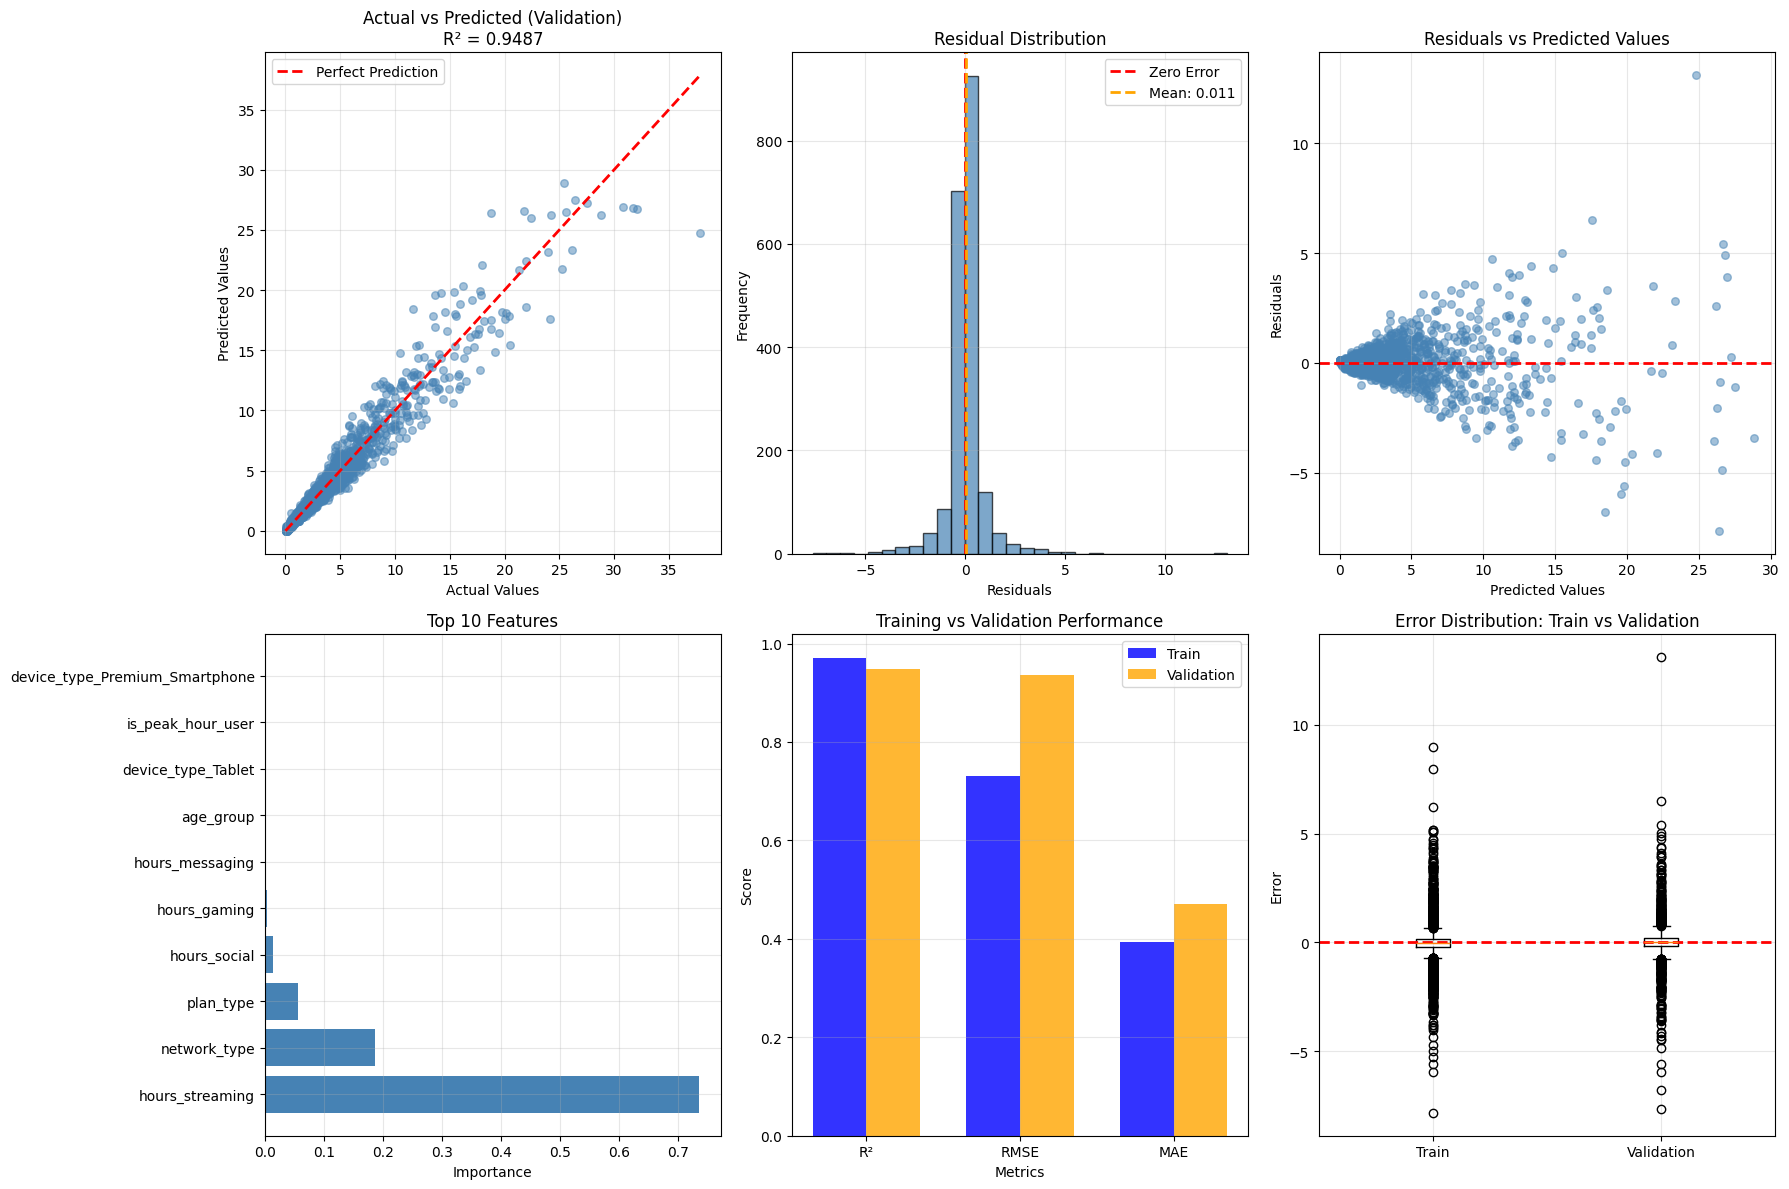

In [87]:
def create_final_visualizations(model, X_train, y_train, X_val, y_val, 
                                y_train_pred, y_val_pred, feature_importance_df=None):
    """Create comprehensive visualizations for final model."""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Actual vs Predicted (Validation)
    ax1 = axes[0, 0]
    ax1.scatter(y_val, y_val_pred, alpha=0.5, s=30, color='steelblue')
    min_val = min(y_val.min(), y_val_pred.min())
    max_val = max(y_val.max(), y_val_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    ax1.set_xlabel('Actual Values')
    ax1.set_ylabel('Predicted Values')
    ax1.set_title(f'Actual vs Predicted (Validation)\nR² = {r2_score(y_val, y_val_pred):.4f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Residuals Distribution
    ax2 = axes[0, 1]
    residuals = y_val - y_val_pred
    ax2.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
    ax2.axvline(x=residuals.mean(), color='orange', linestyle='--', 
               linewidth=2, label=f'Mean: {residuals.mean():.3f}')
    ax2.set_xlabel('Residuals')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Residual Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Residuals vs Predicted
    ax3 = axes[0, 2]
    ax3.scatter(y_val_pred, residuals, alpha=0.5, s=30, color='steelblue')
    ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax3.set_xlabel('Predicted Values')
    ax3.set_ylabel('Residuals')
    ax3.set_title('Residuals vs Predicted Values')
    ax3.grid(True, alpha=0.3)
    
    # 4. Feature Importance - AUTOMATICALLY GET NAMES
    ax4 = axes[1, 0]
    importance = model.feature_importances_
    
    # Get feature names automatically
    if feature_importance_df is not None:
        # Use the pre-computed feature importance DataFrame
        imp_df = feature_importance_df.head(10).copy()
    elif hasattr(X_train, 'columns'):
        # Get from DataFrame columns
        feature_names = X_train.columns.tolist()
        imp_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance
        }).sort_values('Importance', ascending=False).head(10)
    else:
        # Fallback: check if model has feature names
        if hasattr(model, 'feature_names_in_'):
            feature_names = model.feature_names_in_
            imp_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importance
            }).sort_values('Importance', ascending=False).head(10)
        else:
            # Last resort: generic names
            feature_names = [f'Feature_{i}' for i in range(len(importance))]
            imp_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importance
            }).sort_values('Importance', ascending=False).head(10)
    
    ax4.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
    ax4.set_xlabel('Importance')
    ax4.set_title('Top 10 Features')
    ax4.grid(True, alpha=0.3)
    
    # 5. Training vs Validation Performance
    ax5 = axes[1, 1]
    metrics = ['R²', 'RMSE', 'MAE']
    train_metrics = [r2_score(y_train, y_train_pred),
                     np.sqrt(mean_squared_error(y_train, y_train_pred)),
                     mean_absolute_error(y_train, y_train_pred)]
    val_metrics = [r2_score(y_val, y_val_pred),
                   np.sqrt(mean_squared_error(y_val, y_val_pred)),
                   mean_absolute_error(y_val, y_val_pred)]
    
    x = np.arange(len(metrics))
    width = 0.35
    ax5.bar(x - width/2, train_metrics, width, label='Train', alpha=0.8, color='blue')
    ax5.bar(x + width/2, val_metrics, width, label='Validation', alpha=0.8, color='orange')
    ax5.set_xlabel('Metrics')
    ax5.set_ylabel('Score')
    ax5.set_title('Training vs Validation Performance')
    ax5.set_xticks(x)
    ax5.set_xticklabels(metrics)
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Error Distribution (Box Plot)
    ax6 = axes[1, 2]
    errors_train = y_train - y_train_pred
    errors_val = y_val - y_val_pred
    ax6.boxplot([errors_train, errors_val], labels=['Train', 'Validation'])
    ax6.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax6.set_ylabel('Error')
    ax6.set_title('Error Distribution: Train vs Validation')
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_train_processed_df.columns,
    'Importance': final_gb.feature_importances_
}).sort_values('Importance', ascending=False)

# Then create visualizations
fig = create_final_visualizations(
    final_gb,
    X_train_processed_df,
    y_train,
    X_val_processed_df,
    y_val,
    y_train_pred,
    y_val_pred,
    feature_importance
)

In [ ]:
def save_final_model(model, X_train, y_train, X_val, y_val, feature_importance):
  """Save the final model and generate a summary report."""
  
  from datetime import datetime
  import joblib
  
  # Create timestamp
  timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
  
  # 1. Save model
  model_filename = f'gradient_boosting_final_{timestamp}.pkl'
  joblib.dump(model, model_filename)
  print(f"\nModel saved as: {model_filename}")
  
  # 2. Save feature importance
  feature_filename = f'feature_importance_final_{timestamp}.csv'
  feature_importance.to_csv(feature_filename, index=False)
  print(f"Feature importance saved as: {feature_filename}")
  
  # 3. Generate summary report
  report = f"""
======================================================================
FINAL MODEL SUMMARY REPORT
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
======================================================================

MODEL INFORMATION
----------------------------------------------------------------------
Model Type: Gradient Boosting Regressor
Random Seed: 42
Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

BEST PARAMETERS
----------------------------------------------------------------------
subsample: {model.subsample}
n_estimators: {model.n_estimators}
min_samples_split: {model.min_samples_split}
min_samples_leaf: {model.min_samples_leaf}
max_features: {model.max_features}
max_depth: {model.max_depth}
learning_rate: {model.learning_rate}

PERFORMANCE METRICS
----------------------------------------------------------------------
Training Performance:
  R²:    {r2_score(y_train, model.predict(X_train)):.4f}
  RMSE:  {np.sqrt(mean_squared_error(y_train, model.predict(X_train))):.4f}
  MAE:   {mean_absolute_error(y_train, model.predict(X_train)):.4f}

Validation Performance:
  R²:    {r2_score(y_val, model.predict(X_val)):.4f}
  RMSE:  {np.sqrt(mean_squared_error(y_val, model.predict(X_val))):.4f}
  MAE:   {mean_absolute_error(y_val, model.predict(X_val)):.4f}

Cross-Validation (5-fold):
  Mean R²: {cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean():.4f}
  Std R²:  {cross_val_score(model, X_train, y_train, cv=5, scoring='r2').std():.4f}

Overfitting Gap: {r2_score(y_train, model.predict(X_train)) - r2_score(y_val, model.predict(X_val)):.4f}

TOP 10 FEATURES
----------------------------------------------------------------------
{feature_importance.head(10)[['Feature', 'Percentage']].to_string(index=False)}

FILES SAVED
----------------------------------------------------------------------
- {model_filename}
- {feature_filename}

======================================================================
END OF REPORT
======================================================================
"""
  
  # Save report
  report_filename = f'model_report_{timestamp}.txt'
  with open(report_filename, 'w') as f:
    f.write(report)
  print(f"Report saved as: {report_filename}")
  
  return model_filename, feature_filename, report_filename

# Save everything
model_file, feature_file, report_file = save_final_model(
  final_gb,
  X_train_processed, y_train,
  X_val_processed, y_val,
  feature_importance
)